In [12]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from core.GraphCreator import GraphCreator
from core.PlotGraph import plotGraph
import core.PlotGraph
from importlib import reload

In [13]:
output = pd.read_csv("output.csv")
inputs = pd.read_csv("config/atomicInputs.csv")
inputs.set_index("node", inplace=True)
display(output)

,node,SCT
0,crystal_chronicles:bronchus_planks,0.375
1,crystal_chronicles:thunderstone_brick_stairs,0.100
2,suppsquared:item_shelf_jungle,0.282
3,crystal_chronicles:holy_marble_slab,0.050
4,born_in_chaos_v1:great_reaper_axe,842.000
...,...,...
3917,minecraft:ward_armor_trim_smithing_template,280.100
3918,minecraft:rib_armor_trim_smithing_template,280.100
3919,minecraft:diamond_block,360.000
3920,minecraft:diamond,40.000


# Outliers

In [14]:
display(output[output["SCT"] > 1e4])

,node,SCT
554,sophisticatedstorage:stack_upgrade_tier_5,19196.508
594,tiab:time_in_a_bottle,27768.964
627,sophisticatedbackpacks:everlasting_upgrade,12264.800
672,sophisticatedstorage:stack_upgrade_omega_tier,172763.569
705,hazennstuff:eldritch_upgrade_orb,19919.706
825,stonkstimecore:slot_machine,21751.054
1092,hazennstuff:abomination,11998.703
1126,stonkstimecore:stonks_temporal_chronoscope,33395.840
1298,stonkstimecore:time_gear,21600.000
1940,hazennstuff:nights_edge,10121.820


In [15]:
with open('fullGraph-solved.gpickle', 'rb') as f:
    gc : GraphCreator = pickle.load(f)

for n,data in gc.G.nodes.data():
    if data["type"] == "cycle":
        for subnode,subdata in data["subgraph"].nodes.data():
            gc.originalGraph.nodes[subnode]["SCT"] = subdata["SCT"]
            if "originalSCT" in subdata:
                print(n,subnode,subdata["originalSCT"])
    else:
        gc.originalGraph.nodes[n]["SCT"] = data["SCT"]


cycle-0 Ingredient@8fe0010b {0.1}
cycle-1 somemoreblocks:cut_netherite {6804.0}
cycle-1 somemoreblocks:netherite_bricks {6804.0}
cycle-2 Ingredient@71fd713e {0.28800000000000003}
cycle-2 irons_spellbooks:arcane_ingot {50.28}
cycle-2 create:filling-irons_spellbooks:filling/arcane_ingot {26.0}
cycle-3 crafting-farmersdelight:magenta_canvas_sign {0.1}
cycle-3 crafting-farmersdelight:black_canvas_sign {1.0}
cycle-3 crafting-farmersdelight:brown_canvas_sign {0.1}
cycle-3 crafting-farmersdelight:orange_canvas_sign {0.1}
cycle-3 crafting-farmersdelight:blue_canvas_sign {0.1}
cycle-3 crafting-farmersdelight:gray_canvas_sign {0.1}
cycle-3 Ingredient@669464bf {3.229}
cycle-3 crafting-farmersdelight:yellow_canvas_sign {0.1}
cycle-3 crafting-farmersdelight:purple_canvas_sign {0.1}
cycle-3 crafting-farmersdelight:light_blue_canvas_sign {0.1}
cycle-3 crafting-farmersdelight:pink_canvas_sign {0.1}
cycle-3 crafting-farmersdelight:lime_canvas_sign {0.1}
cycle-3 crafting-farmersdelight:white_canvas_sign

In [16]:
def neighborhood(G,source,n):
    nodes = {source}
    for _ in range(n):
        for node in nodes.copy():
            nodes.update(set(list(G.predecessors(node))))
    return nx.subgraph(G,nodes)

In [11]:
from pyvis.network import Network

def plot(G, name, mainNode, fixedInOut=True):
    g = Network(width="80%", height=1000, directed=True, select_menu=True, filter_menu=True, layout=True, notebook=False)
    g.show_buttons(["physics","layout"])
    g.options.edges.smooth.enabled = False
    G = cleanupGraph(G)
    g.from_nx(G.copy())


    # Get source and sink nodes
    for n in g.nodes:
        nid = n["id"]
        n["size"] = G.nodes[nid].get("size", 30)
        if mainNode == nid:
            n["color"] = "purple"
        else:
            n["color"] = G.nodes[nid].get("color", "gray") if nid not in inputs.index else "red"
        n["shape"] = G.nodes[nid].get("shape", "circle")
        n["font"] = {"size":10}
        n["title"] = G.nodes[nid].get("SCT", "")

    for e in g.edges:
        src, dst = e['from'], e['to']
        weight = G[src][dst].get("weight", 0)
        e['label'] = str(weight)
        e["font"] = {"size": 15, "color": "black"}
        e['arrows'] = 'to'
        e['arrowStrikethrough'] = False
        e['width'] = 1 + 2 * np.log10(weight+1)
        e['smooth'] = False

    #g.barnes_hut(spring_strength=1, spring_length=1000, overlap=1)
    g.options.layout.hierarchical.enabled = fixedInOut
    g.options.layout.hierarchical.sortMethod = "hubsize"
    g.show(f"{name}.html", notebook=False)

def cleanupGraph(G):
    G = G.copy()
    for n,data in G.nodes.data():
        if data["type"] == "cycle":
            del G.nodes[n]["subgraph"]
        G.nodes[n].update(sanitize(data))
    return G

def sanitize(obj):
    if isinstance(obj, set):
        return list(obj)
    if isinstance(obj, dict):
        return {k: sanitize(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [sanitize(v) for v in obj]
    return obj

tofind = "hazennstuff:giorno_giovanna_helmet"
plot(neighborhood(gc.originalGraph, tofind, 10), tofind.split(':')[-1].replace('/','_'), tofind, fixedInOut=True)

giorno_giovanna_helmet.html


# Distribution

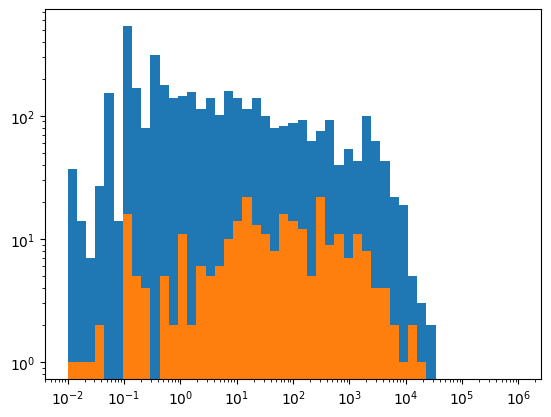

In [114]:
plt.figure()
plt.hist(output['SCT'],bins=np.geomspace(0.01, 1e6, 50))
plt.hist(inputs['value'],bins=np.geomspace(0.01, 1e6, 50))
plt.xscale('log')
plt.yscale('log')
plt.show()